# Chain Model Evaluation - US Traffic Incident Analysis
ในขั้นตอนนี้เราจะนำ Model ทั้งสองตัวที่ Train ไว้มาทดสอบกับ Test Set โดยใช้กระบวนการแบบ Chain:
1. ใช้ **Model 1** ทำนาย `Distance(mi)` จาก Features พื้นฐาน
2. นำ `Distance(mi)` ที่ทำนายได้ ไปรวมกับ Features พื้นฐาน
3. ใช้ **Model 2** ทำนาย `Duration(min)`
4. วัดผลลัพธ์สุดท้ายเปรียบเทียบกับคำตอบจริง (Ground Truth)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load Test Data & Models

In [2]:
# โหลด Features ของ Test Set
X_test = pd.read_csv("../data/processed/03/test_features.csv")

# Bool columns from CSV stay as bool dtype — cast to int so XGBoost treats them as numeric
bool_cols = X_test.select_dtypes(include='bool').columns.tolist()
X_test[bool_cols] = X_test[bool_cols].astype(int)

# โหลดคำตอบจริง (Ground Truth)
y_true = pd.read_csv("../data/processed/01.2/test_secret_answers.csv")

# โหลด Models & Metadata
model_dist = joblib.load("../models/chain_dist_model.pkl")
model_dur  = joblib.load("../models/chain_dur_model.pkl")
metadata   = joblib.load("../models/chain_metadata.pkl")

num_features     = metadata["num_features"]
num_features_dur = metadata["num_features_dur"]
USE_LOG_TARGET   = metadata["use_log_target"]

print(f"X_test shape      : {X_test.shape}")
print(f"y_true shape      : {y_true.shape}")
print(f"num_features      : {len(num_features)}")
print(f"num_features_dur  : {len(num_features_dur)}")
print(f"use_log_target    : {USE_LOG_TARGET}")

X_test shape      : (1367273, 60)
y_true shape      : (1367273, 2)
num_features      : 46
num_features_dur  : 47
use_log_target    : True


## 2. Step 1: Predict Distance
ใช้ Model 1 ทำนายระยะทาง

In [3]:
print("Predicting Distance...")
# Select only the numeric features the model was trained on
X_test_dist = X_test[num_features].astype('float32')
pred_distance_log = model_dist.predict(X_test_dist)

# 1. ใช้ค่าที่เป็น LOG ส่งต่อให้ Model 2 (เพราะ Model 2 ถูก Train ด้วยฟีเจอร์ที่เป็น Log)
X_test_dur = X_test[num_features].astype('float32').copy()
X_test_dur["Distance(mi)"] = pred_distance_log
X_test_dur = X_test_dur[num_features_dur].astype('float32')

# 2. กลับค่าเป็นสเกลปกติเพื่อวัดผล MAE/RMSE ของ Distance
pred_distance = np.expm1(pred_distance_log) if USE_LOG_TARGET else pred_distance_log
pred_distance = np.clip(pred_distance, 0, None)

# ตรวจสอบผลลัพธ์ของ Model 1
dist_mae  = mean_absolute_error(y_true["Distance(mi)"], pred_distance)
dist_rmse = np.sqrt(mean_squared_error(y_true["Distance(mi)"], pred_distance))
dist_r2   = r2_score(y_true["Distance(mi)"], pred_distance)
print(f"Distance  MAE : {dist_mae:.4f}")
print(f"Distance  RMSE: {dist_rmse:.4f}")
print(f"Distance  R²  : {dist_r2:.4f}")

Predicting Distance...
Distance  MAE : 0.4342
Distance  RMSE: 0.9562
Distance  R²  : 0.2046


## 3. Step 2: Predict Duration using Predicted Distance
นำผลลัพธ์จาก Step 1 มาเป็น Feature ให้ Model 2

In [4]:
print("Predicting Duration...")
pred_duration_log = model_dur.predict(X_test_dur)
pred_duration = np.expm1(pred_duration_log) if USE_LOG_TARGET else pred_duration_log
pred_duration = np.clip(pred_duration, 0, None)

# ตรวจสอบผลลัพธ์ของ Model 2 (Final Prediction)
dur_mae  = mean_absolute_error(y_true["Duration(min)"], pred_duration)
dur_rmse = np.sqrt(mean_squared_error(y_true["Duration(min)"], pred_duration))
dur_r2   = r2_score(y_true["Duration(min)"], pred_duration)

print(f"\n--- Final Evaluation (Duration) ---")
print(f"MAE:  {dur_mae:.4f} minutes")
print(f"RMSE: {dur_rmse:.4f} minutes")
print(f"R2:   {dur_r2:.4f}")

Predicting Duration...

--- Final Evaluation (Duration) ---
MAE:  57.3315 minutes
RMSE: 109.3255 minutes
R2:   0.2309


## 4. Visualize Results

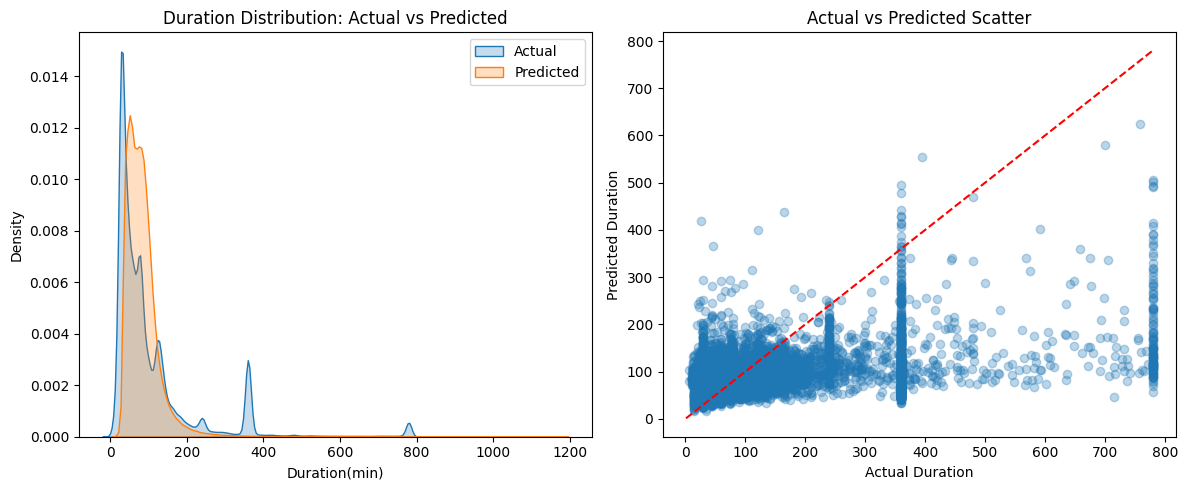

In [5]:
plt.figure(figsize=(12, 5))

# Plot Distribution ของผลการทำนาย vs ความจริง
plt.subplot(1, 2, 1)
sns.kdeplot(y_true["Duration(min)"], label='Actual', fill=True)
sns.kdeplot(pred_duration, label='Predicted', fill=True)
plt.title("Duration Distribution: Actual vs Predicted")
plt.legend()

# Scatter Plot แสดงความสัมพันธ์ (สุ่มมา 10,000 จุดเพื่อให้กราฟไม่แน่นเกินไป)
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(y_true), 10000, replace=False)
plt.scatter(y_true["Duration(min)"].iloc[sample_idx], pred_duration[sample_idx], alpha=0.3)
plt.plot([y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 
         [y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 'r--')
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted Scatter")

plt.tight_layout()
plt.show()

## 5. Error Analysis
ดูว่าอุบัติเหตุประเภทไหนที่ Model ทำนายพลาดมากที่สุด

In [6]:
error_df = X_test.copy()
error_df['Actual_Duration'] = y_true['Duration(min)']
error_df['Pred_Duration'] = pred_duration
error_df['Absolute_Error'] = np.abs(error_df['Actual_Duration'] - error_df['Pred_Duration'])

print("Top 5 states with highest average error:")
if 'State' in error_df.columns:
    print(error_df.groupby('State')['Absolute_Error'].mean().sort_values(ascending=False).head())
else:
    # ถ้า State ถูก Encode ไปแล้ว ลองดูตาม Weather_Group
    print(error_df.groupby('Weather_Group')['Absolute_Error'].mean().sort_values(ascending=False).head())

Top 5 states with highest average error:
State
WV    124.715781
ME    115.765350
WY    111.298900
OR     95.743051
VT     94.575806
Name: Absolute_Error, dtype: float64


## 6. Error Visualization
วิเคราะห์ความผิดพลาดผ่าน Scatter Plot และ Residual Plot

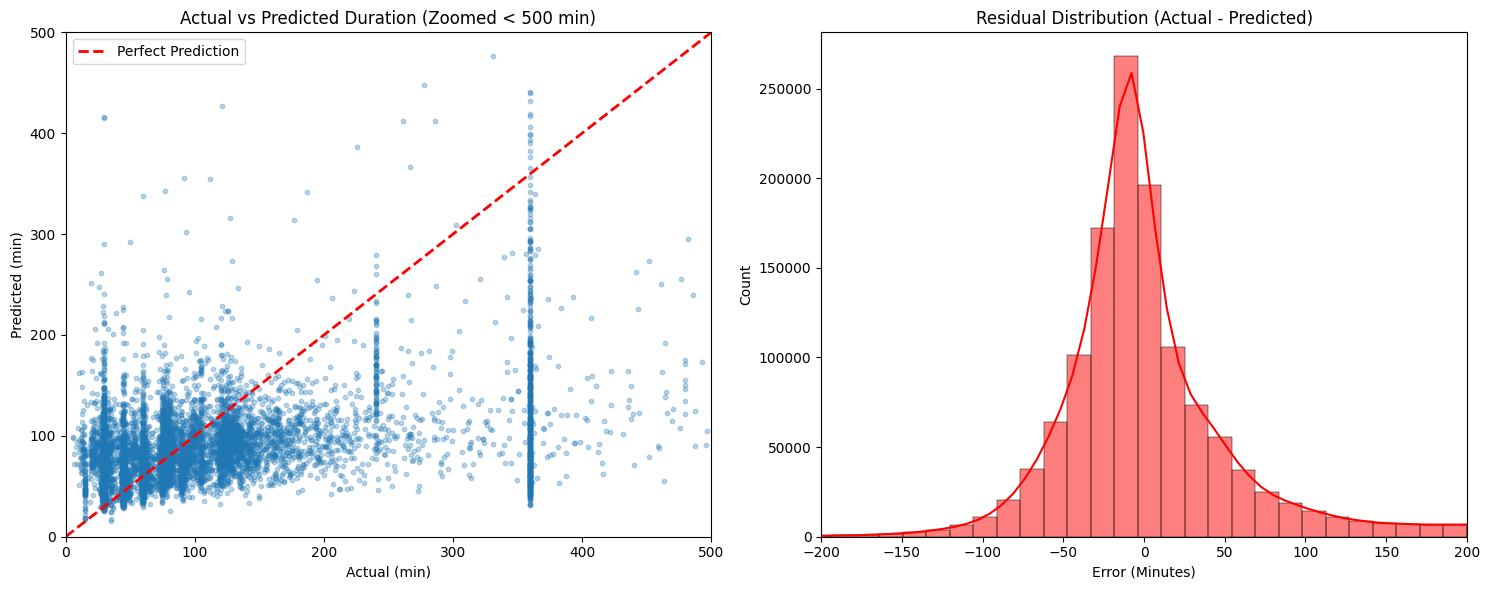

In [7]:
plt.figure(figsize=(15, 6))

# Plot 1: Actual vs Predicted (Duration)
plt.subplot(1, 2, 1)
sample_idx = np.random.choice(len(y_true), min(10000, len(y_true)), replace=False)
plt.scatter(y_true['Duration(min)'].iloc[sample_idx], pred_duration[sample_idx], alpha=0.3, s=10)
max_val = max(y_true['Duration(min)'].max(), pred_duration.max())
plt.plot([0, 500], [0, 500], 'r--', lw=2, label='Perfect Prediction') # Zoom to 500 for clarity
plt.xlim(0, 500); plt.ylim(0, 500)
plt.title("Actual vs Predicted Duration (Zoomed < 500 min)")
plt.xlabel("Actual (min)"); plt.ylabel("Predicted (min)")
plt.legend()

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
residuals = y_true['Duration(min)'] - pred_duration
sns.histplot(residuals, bins=100, kde=True, color='red')
plt.xlim(-200, 200) # Zoom to see common errors
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Error (Minutes)")

plt.tight_layout()
plt.show()

## 6. Comparison Table & Extra Metrics
แสดงตารางเปรียบเทียบค่าจริงกับค่าทำนาย และวัดผลเพิ่มเติม

In [8]:
# 1. สร้าง DataFrame เปรียบเทียบ
comparison_df = pd.DataFrame({
    'Actual Distance (mi)': y_true['Distance(mi)'],
    'Pred Distance (mi)': pred_distance,
    'Actual Duration (min)': y_true['Duration(min)'],
    'Pred Duration (min)': pred_duration
})

print("--- Sample Comparison Table ---")
print(comparison_df.head(20))

# 2. วัดผลเพิ่มเติม
from sklearn.metrics import median_absolute_error

med_ae_dist = median_absolute_error(y_true['Distance(mi)'], pred_distance)
med_ae_dur  = median_absolute_error(y_true['Duration(min)'], pred_duration)

print(f"\n--- Additional Metrics ---")
print(f"Median Absolute Error (Distance): {med_ae_dist:.4f} mi")
print(f"Median Absolute Error (Duration): {med_ae_dur:.4f} min")

# 3. ตรวจสอบความแม่นยำแยกตาม Severity (ถ้ามีใน X_test)
if 'Severity' in X_test.columns:
    comparison_df['Severity'] = X_test['Severity'].values
    sev_eval = comparison_df.groupby('Severity').apply(lambda x: pd.Series({
        'MAE_Duration': mean_absolute_error(x['Actual Duration (min)'], x['Pred Duration (min)']),
        'Sample_Count': len(x)
    }))
    print("\n--- Evaluation by Severity ---")
    print(sev_eval)

# 4. สรุปผลลัพธ์ลงไฟล์ CSV เพื่อความสะดวกในการตรวจ
comparison_df.head(1000).to_csv("../report/prediction_comparison_sample.csv", index=False)
print("\nSaved sample comparison to report/prediction_comparison_sample.csv")

--- Sample Comparison Table ---
    Actual Distance (mi)  Pred Distance (mi)  Actual Duration (min)  \
0                  0.344            1.078651             128.750000   
1                  0.000            0.719305              28.916667   
2                  0.000            0.173162              47.633333   
3                  0.000            0.051256              91.633333   
4                  0.000            0.310594              43.916667   
5                  0.010            0.133195              45.416667   
6                  0.000            0.179286              29.766667   
7                  0.878            0.720010              95.033333   
8                  0.000            0.323815              29.400000   
9                  0.000            0.271845              78.900000   
10                 0.000            0.206888              59.800000   
11                 0.104            0.430447             121.900000   
12                 0.000            0.022174 

C:\Users\PC\AppData\Local\Temp\ipykernel_32536\2409416989.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sev_eval = comparison_df.groupby('Severity').apply(lambda x: pd.Series({
